In [183]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [184]:
# Load Data set 

path = "D:/Personal/MSc/MSc. Data Science/Lecture Notes/2. Principles of DS/Assignment and Passpapers/Assignments/Portfolio/Group Work/time series data.csv"
df = pd.read_csv(path)

# Check Point 1 - Veryfy loaded data 
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB
None
   t  ProductP1  ProductP2  ProductP3  ProductP4  ProductP5  price  \
0  1        197         66        266        113          2      1   
1  2        153         44        264         74          1      2   
2  3        128         55        317        116          0      1   
3  4        133         57        390         70          0      2   
4  5        120         47        440        141          1      1   

   temperature  
0           18  

In [185]:
# Check the "t" value 
print(df["t"].head())  # Check the first few values

0    1
1    2
2    3
3    4
4    5
Name: t, dtype: int64


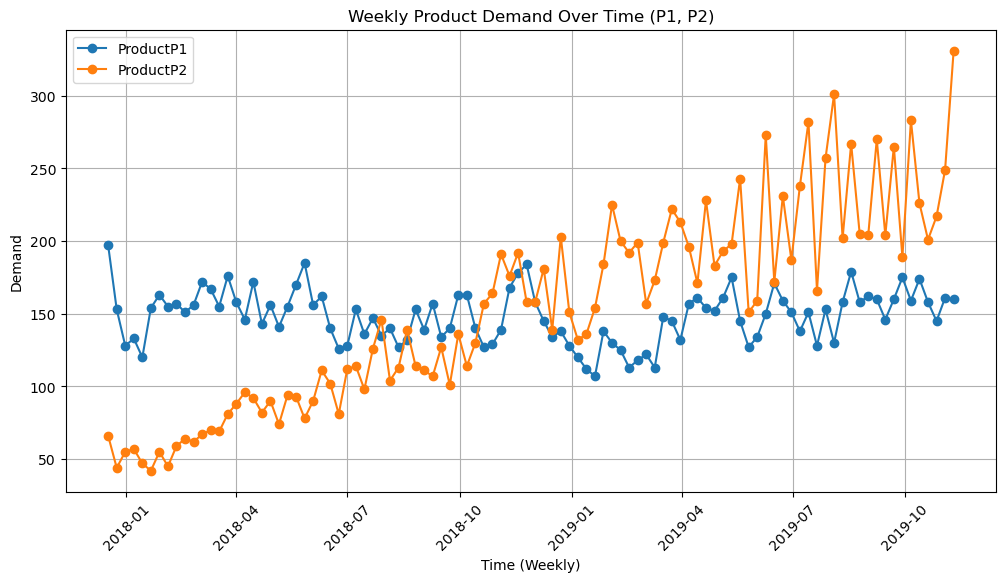

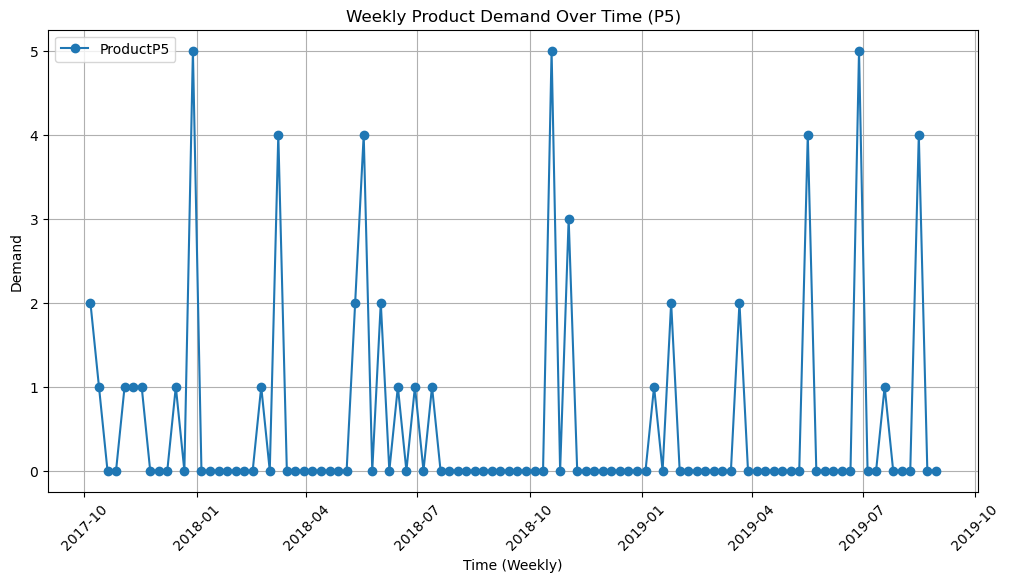

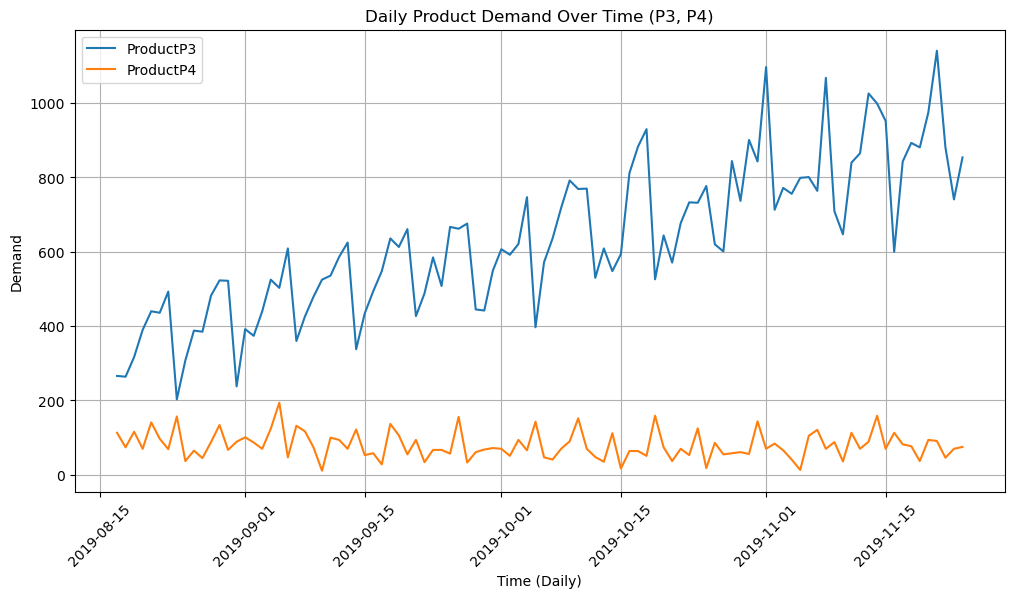

In [186]:
# Plot data in similar time intervals 

# Define the last known dates for each product type
lastdate_p1_p2 = pd.to_datetime("2019-11-10")  # Last date for P1, P2 (weekly)
lastdate_p3_p4 = pd.to_datetime("2019-11-24")  # Last date for P3, P4 (daily)
lastdate_p5 = pd.to_datetime("2019-08-30")  # Last date for P5 (weekly)

# Reverse time calculation based on the number of entries
df["t_daily"] = lastdate_p3_p4 - pd.to_timedelta(df["t"].max() - df["t"], unit="D")  # Daily data (P3, P4)
df["t_weekly_p1_p2"] = lastdate_p1_p2 - pd.to_timedelta((df["t"].max() - df["t"]) * 7, unit="D")  # Weekly data (P1, P2)
df["t_weekly_p5"] = lastdate_p5 - pd.to_timedelta((df["t"].max() - df["t"]) * 7, unit="D")  # Weekly data (P5)

# Plot Weekly Data (P1, P2)
plt.figure(figsize=(12, 6))
for col in ["ProductP1", "ProductP2"]:
    plt.plot(df["t_weekly_p1_p2"], df[col], label=col, marker="o")

plt.xlabel("Time (Weekly)")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time (P1, P2)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Plot Weekly Data (P5)
plt.figure(figsize=(12, 6))
plt.plot(df["t_weekly_p5"], df["ProductP5"], label="ProductP5", marker="o")

plt.xlabel("Time (Weekly)")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time (P5)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Plot Daily Data (P3, P4)
plt.figure(figsize=(12, 6))
for col in ["ProductP3", "ProductP4"]:
    plt.plot(df["t_daily"], df[col], label=col)

plt.xlabel("Time (Daily)")
plt.ylabel("Demand")
plt.legend()
plt.title("Daily Product Demand Over Time (P3, P4)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


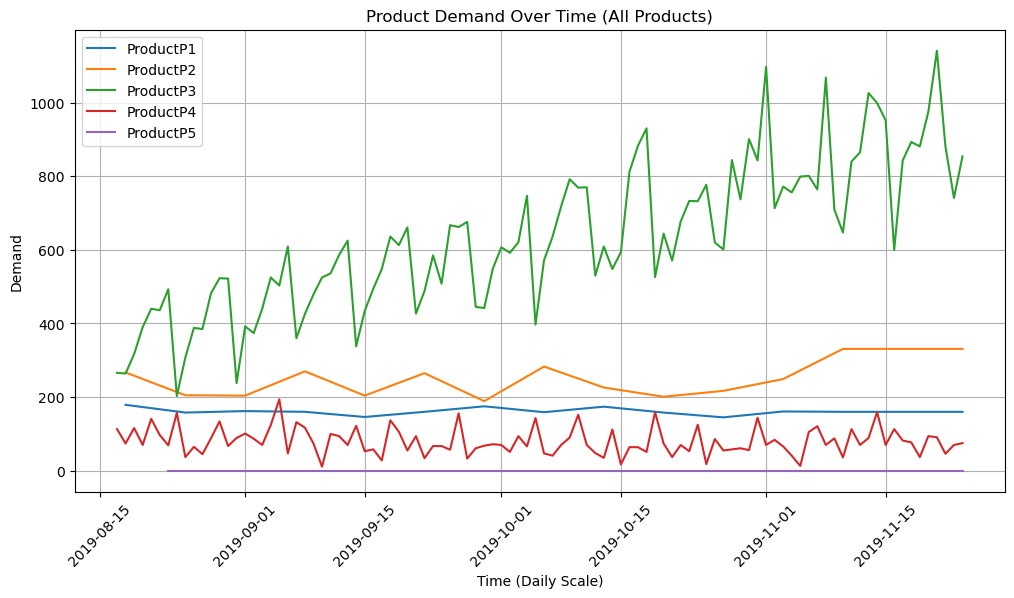

In [187]:
# plot all data in same grapha 

# Interpolate weekly data to match daily scale
df_interpolated = df.set_index("t_daily").reindex(pd.date_range(df["t_daily"].min(), df["t_daily"].max(), freq="D"))
df_interpolated["ProductP1"] = df.set_index("t_weekly_p1_p2")["ProductP1"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP2"] = df.set_index("t_weekly_p1_p2")["ProductP2"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP5"] = df.set_index("t_weekly_p5")["ProductP5"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP3"] = df.set_index("t_daily")["ProductP3"].reindex(df_interpolated.index)
df_interpolated["ProductP4"] = df.set_index("t_daily")["ProductP4"].reindex(df_interpolated.index)

# Plot all products in the same chart
plt.figure(figsize=(12, 6))

for col in ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]:
    plt.plot(df_interpolated.index, df_interpolated[col], label=col)

plt.xlabel("Time (Daily Scale)")
plt.ylabel("Demand")
plt.legend()
plt.title("Product Demand Over Time (All Products)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


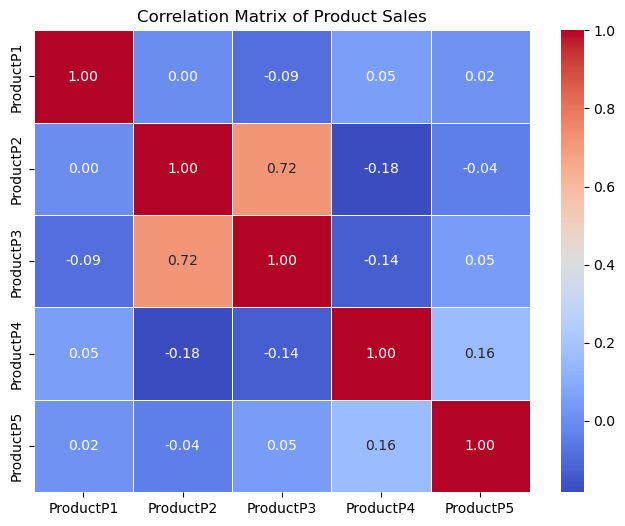

In [188]:
# Compute correlation matrix between the five products
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


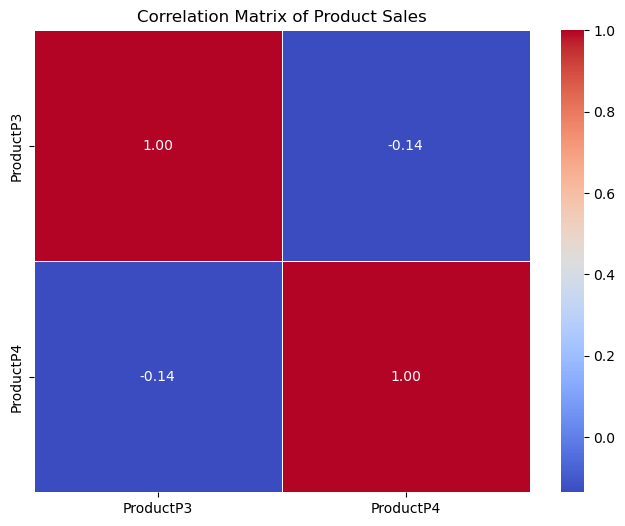

In [189]:
# Compute correlation matrix between the P3 and P4
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP3", "ProductP4"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


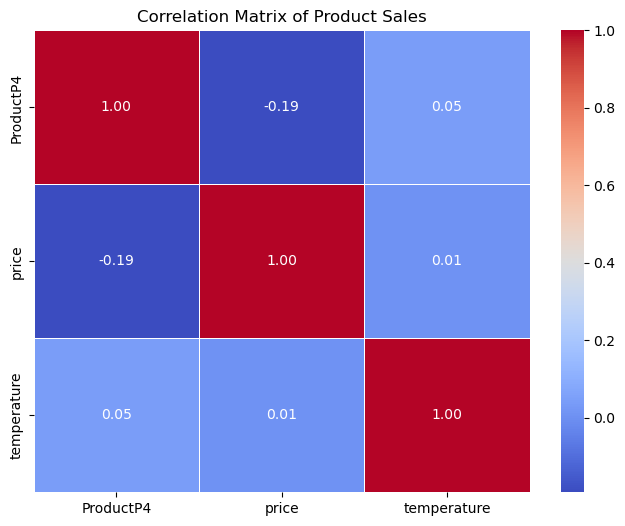

In [190]:
# Compute correlation matrix between the P4 and Price and Temparature 
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP4", "price", "temperature"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


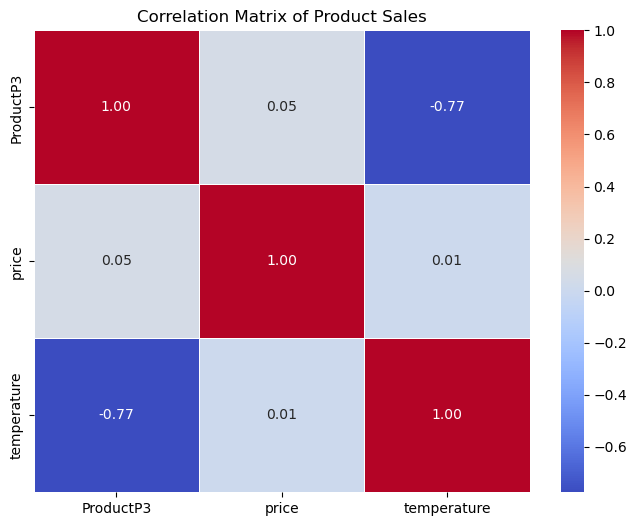

In [191]:
# Compute correlation matrix between the P3 and Price and Temparature 
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP3", "price", "temperature"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


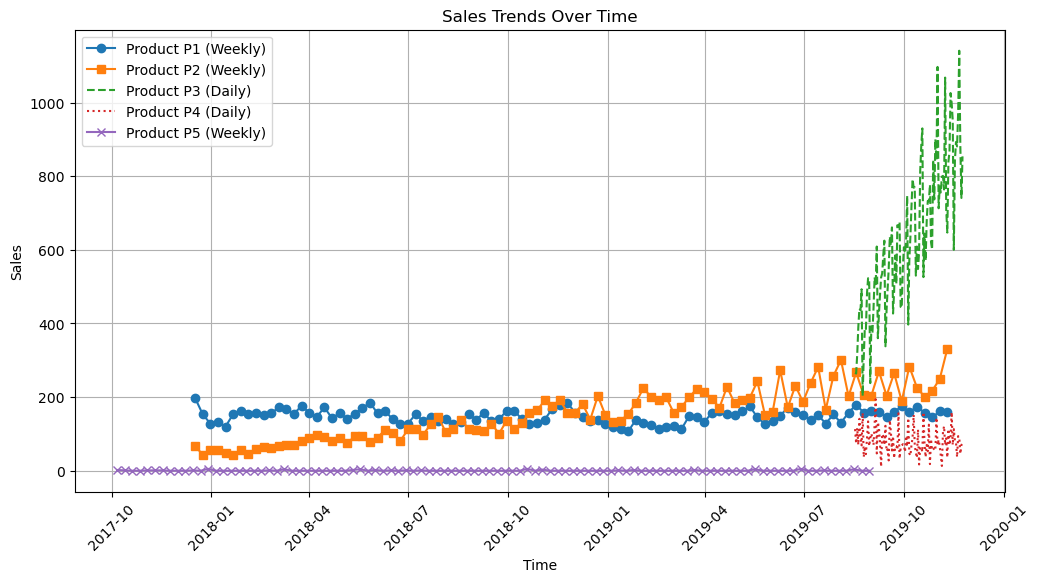

In [192]:
# Plot trends for each product
plt.figure(figsize=(12, 6))
plt.plot(df["t_weekly_p1_p2"], df["ProductP1"], label="Product P1 (Weekly)", marker="o")
plt.plot(df["t_weekly_p1_p2"], df["ProductP2"], label="Product P2 (Weekly)", marker="s")
plt.plot(df["t_daily"], df["ProductP3"], label="Product P3 (Daily)", linestyle="dashed")
plt.plot(df["t_daily"], df["ProductP4"], label="Product P4 (Daily)", linestyle="dotted")
plt.plot(df["t_weekly_p5"], df["ProductP5"], label="Product P5 (Weekly)", marker="x")

# Labels and legend
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Sales Trends Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show plot
plt.show()


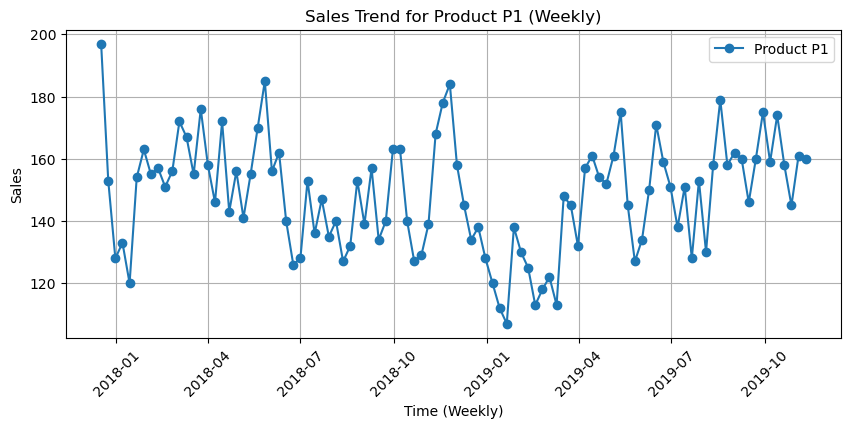

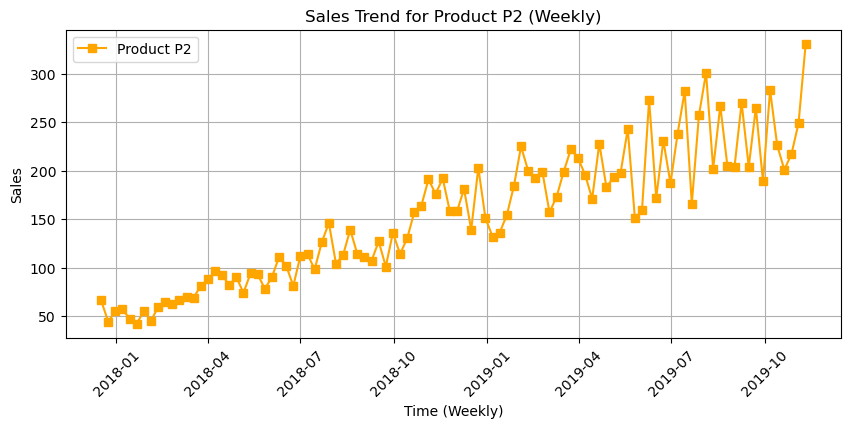

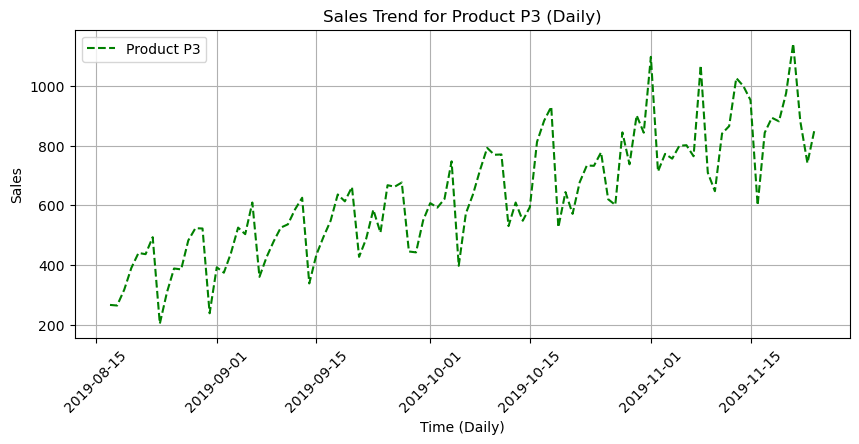

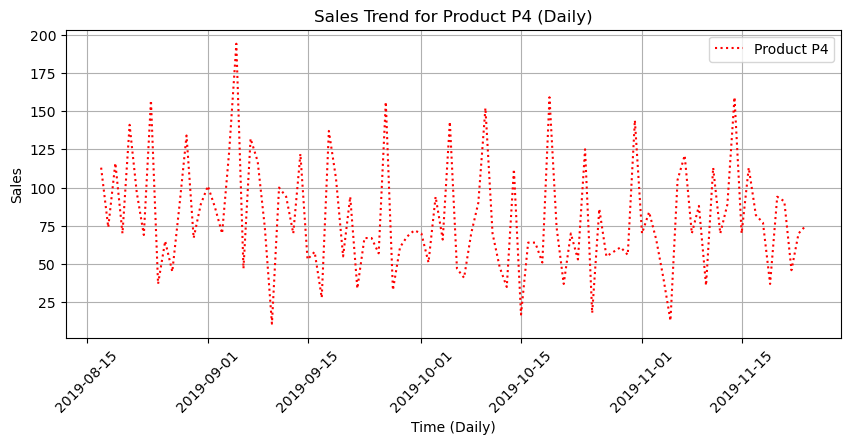

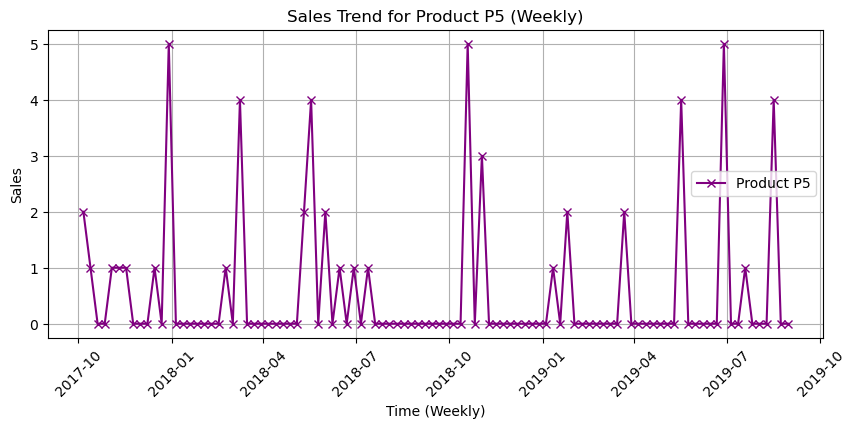

In [193]:
# Plot each product's sales trends separately

# Product P1 (Weekly)
plt.figure(figsize=(10, 4))
plt.plot(df["t_weekly_p1_p2"], df["ProductP1"], marker="o", label="Product P1")
plt.xlabel("Time (Weekly)")
plt.ylabel("Sales")
plt.title("Sales Trend for Product P1 (Weekly)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Product P2 (Weekly)
plt.figure(figsize=(10, 4))
plt.plot(df["t_weekly_p1_p2"], df["ProductP2"], marker="s", label="Product P2", color='orange')
plt.xlabel("Time (Weekly)")
plt.ylabel("Sales")
plt.title("Sales Trend for Product P2 (Weekly)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Product P3 (Daily)
plt.figure(figsize=(10, 4))
plt.plot(df["t_daily"], df["ProductP3"], linestyle="dashed", label="Product P3", color='green')
plt.xlabel("Time (Daily)")
plt.ylabel("Sales")
plt.title("Sales Trend for Product P3 (Daily)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Product P4 (Daily)
plt.figure(figsize=(10, 4))
plt.plot(df["t_daily"], df["ProductP4"], linestyle="dotted", label="Product P4", color='red')
plt.xlabel("Time (Daily)")
plt.ylabel("Sales")
plt.title("Sales Trend for Product P4 (Daily)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Product P5 (Weekly)
plt.figure(figsize=(10, 4))
plt.plot(df["t_weekly_p5"], df["ProductP5"], marker="x", label="Product P5", color='purple')
plt.xlabel("Time (Weekly)")
plt.ylabel("Sales")
plt.title("Sales Trend for Product P5 (Weekly)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()


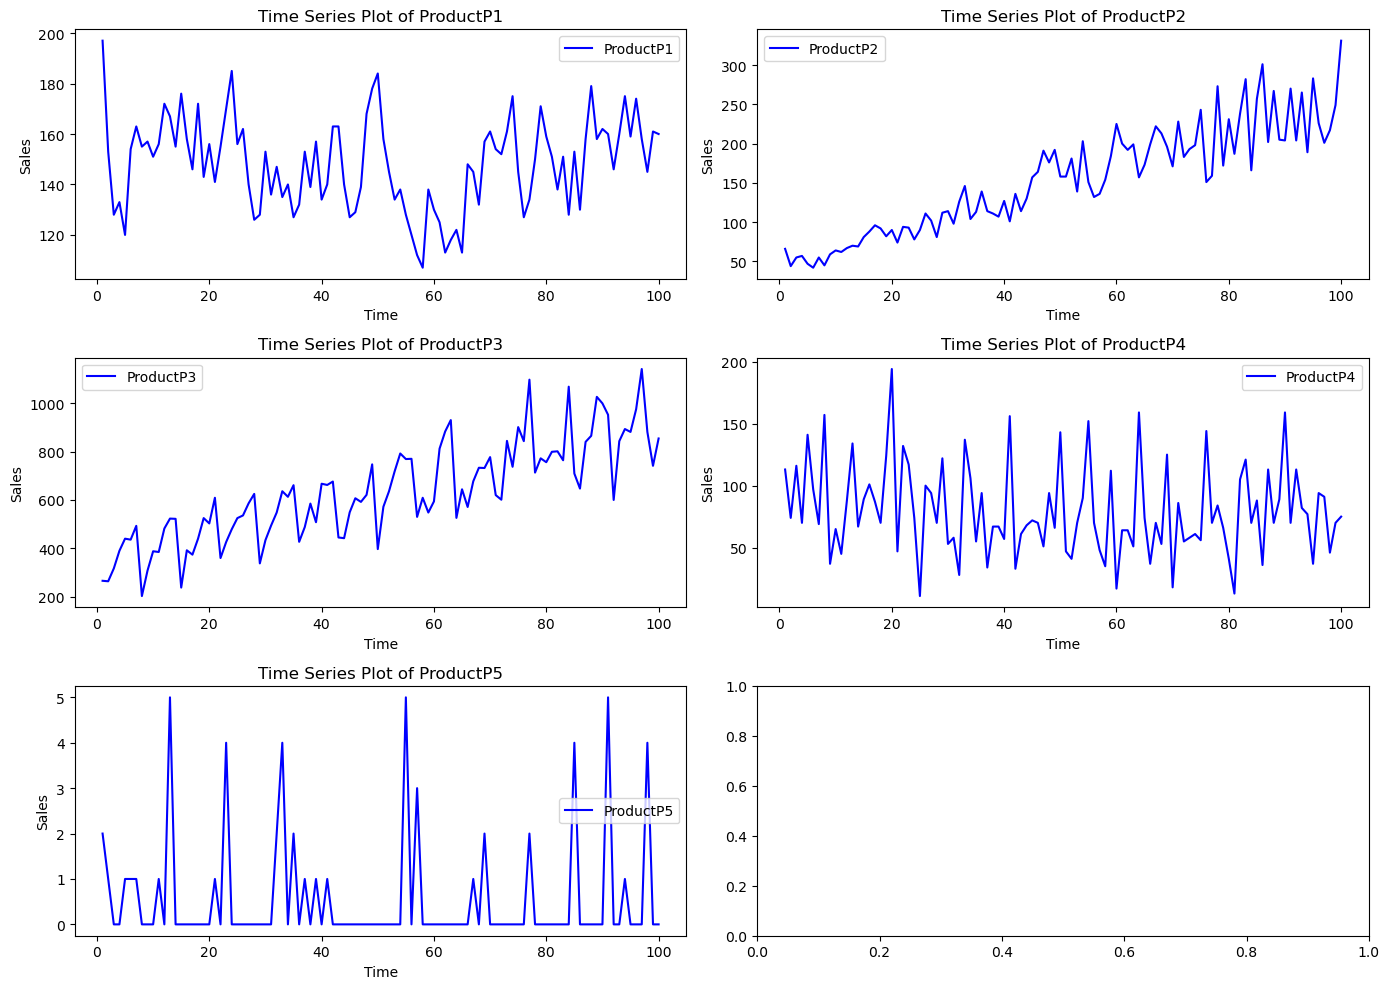

{'ProductP1': {'ADF Statistic': -5.675633394124423,
  'p-value': 8.718203196079533e-07},
 'ProductP2': {'ADF Statistic': -0.8615506650073329,
  'p-value': 0.8003705824294141},
 'ProductP3': {'ADF Statistic': -0.2348731223826701,
  'p-value': 0.9342351563563018},
 'ProductP4': {'ADF Statistic': -11.455482825126904,
  'p-value': 5.7205444486806576e-21},
 'ProductP5': {'ADF Statistic': -11.152511228832301,
  'p-value': 2.9198433474930944e-20}}

In [194]:
from statsmodels.tsa.stattools import adfuller

# Plot time series data for each product
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

products = ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]
for i, product in enumerate(products):
    ax = axes[i // 2, i % 2]
    ax.plot(df["t"], df[product], label=product, color="b")
    ax.set_title(f"Time Series Plot of {product}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Sales")
    ax.legend()

plt.tight_layout()
plt.show()

# Check stationarity using ADF test
adf_results = {}
for product in products:
    adf_test = adfuller(df[product])
    adf_results[product] = {"ADF Statistic": adf_test[0], "p-value": adf_test[1]}

# Display ADF test results
adf_results


ADF Test for P2_diff: {'ADF Statistic': -5.76181610187488, 'p-value': 5.649369037917615e-07}
ADF Test for P3_diff: {'ADF Statistic': -6.009312594393355, 'p-value': 1.5874497602073968e-07}


C:\Users\suneth.jayamanne\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\suneth.jayamanne\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\suneth.jayamanne\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\suneth.jayamanne\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\suneth.jayamanne\AppData\Local\anaconda3\Lib\site-p

Final Forecasts for all Products:
      ProductP1  ProductP4  ProductP5   ProductP2   ProductP3
101  152.780262  80.405739   0.217179  265.938917  937.596420
102  151.255742  80.142072   0.882887  268.216851  943.698839
103  150.375065  80.094447   0.217182  270.348468  949.583243
104  149.866319  80.085844   0.882885  272.497341  955.431014
105  149.572429  80.084291   0.217184  274.644178  961.272630
106  149.402656  80.084010   0.882882  276.791255  967.113211
107  149.304583  80.083959   0.217186  278.938304  972.953619
108  149.247928  80.083950   0.882880  281.085357  978.793997
109  149.215200  80.083948   0.217189         NaN         NaN
110         NaN        NaN        NaN         NaN         NaN


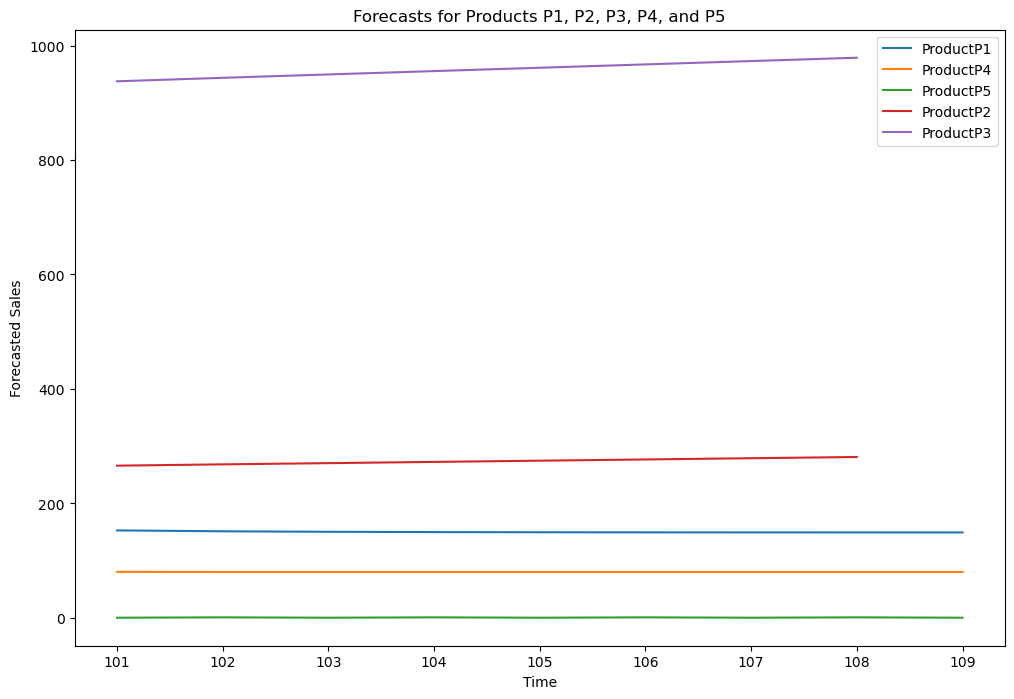

In [195]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Assume the data is loaded into df
# df = pd.read_csv("your_file.csv")

# Define forecast horizon
forecast_horizon = 10
last_time = df["t"].max()
future_index = list(range(last_time + 1, last_time + 1 + forecast_horizon))

# -------------------------
# Step 1: Handle Stationarity
# -------------------------
# For P2 and P3, apply first-order differencing
df["ProductP2_diff"] = df["ProductP2"].diff()
df["ProductP3_diff"] = df["ProductP3"].diff()

# Check ADF for differenced series (for reference)
adf_p2 = adfuller(df["ProductP2_diff"].dropna())
adf_p3 = adfuller(df["ProductP3_diff"].dropna())

print("ADF Test for P2_diff:", {"ADF Statistic": adf_p2[0], "p-value": adf_p2[1]})
print("ADF Test for P3_diff:", {"ADF Statistic": adf_p3[0], "p-value": adf_p3[1]})

# -------------------------
# Step 2: Fit ARIMA Models and Forecast
# -------------------------
# For this example, we manually set orders; in practice, you might optimize them.
orders = {
    "ProductP1": (1, 0, 1),
    "ProductP2_diff": (1, 0, 1),  # Fitted on differenced series
    "ProductP3_diff": (1, 0, 1),  # Fitted on differenced series
    "ProductP4": (1, 0, 1),
    "ProductP5": (1, 0, 1)
}

# Dictionary to hold forecasts (on the model scale)
forecasts = {}

# For P1, P4, and P5 (original series)
for prod in ["ProductP1", "ProductP4", "ProductP5"]:
    model = ARIMA(df[prod].dropna(), order=orders[prod])
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=forecast_horizon)
    forecasts[prod] = forecast

# For P2 and P3 (differenced series)
for prod in ["ProductP2_diff", "ProductP3_diff"]:
    model = ARIMA(df[prod].dropna(), order=orders[prod])
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=forecast_horizon)
    forecasts[prod] = forecast

# -------------------------
# Step 3: Revert Differencing for P2 and P3
# -------------------------
final_forecasts = {}

# For products with forecasts on original scale (P1, P4, P5), use directly:
for prod in ["ProductP1", "ProductP4", "ProductP5"]:
    final_forecasts[prod] = forecasts[prod]

# For P2 and P3, we need to add the cumulative sum of forecasted differences to the last observed value.
for orig, diff in zip(["ProductP2", "ProductP3"], ["ProductP2_diff", "ProductP3_diff"]):
    # Get the last observed value from the original series
    last_value = df[orig].iloc[-1]
    # Forecasted differences for the horizon
    diff_forecast = forecasts[diff]
    # Convert the forecasted differences to the actual level forecasts by taking a cumulative sum and adding last observed value
    cumulative = diff_forecast.cumsum()
    final_forecasts[orig] = last_value + cumulative

# -------------------------
# Step 4: Organize Forecasts in a DataFrame and Display
# -------------------------
final_forecast_df = pd.DataFrame(final_forecasts, index=future_index)
print("Final Forecasts for all Products:")
print(final_forecast_df)

# Optional: Plot the forecasts for visual inspection
plt.figure(figsize=(12, 8))
for prod in final_forecasts:
    plt.plot(final_forecast_df.index, final_forecast_df[prod], label=prod)
plt.xlabel("Time")
plt.ylabel("Forecasted Sales")
plt.title("Forecasts for Products P1, P2, P3, P4, and P5")
plt.legend()
plt.show()


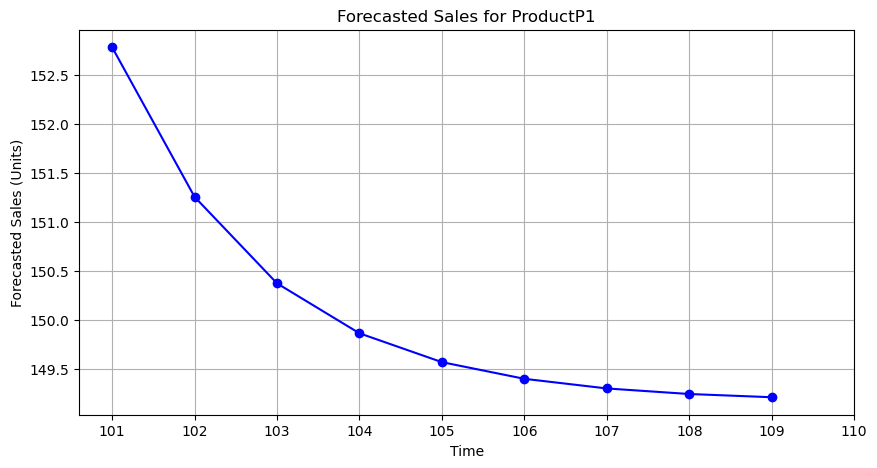

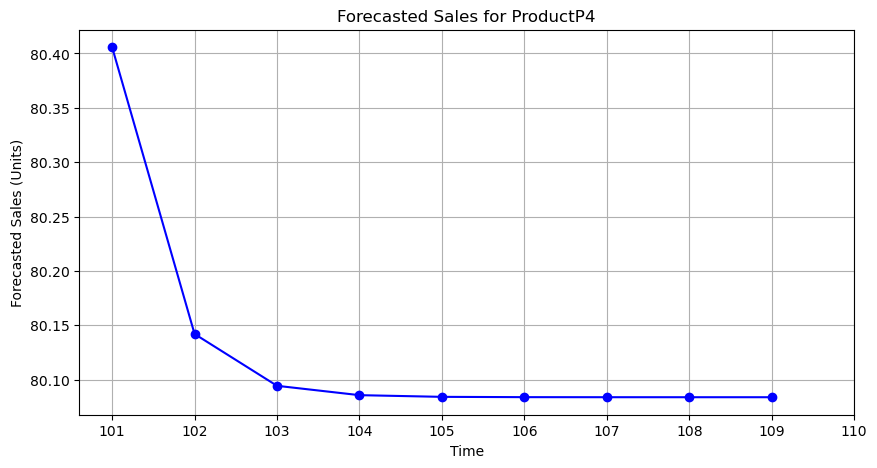

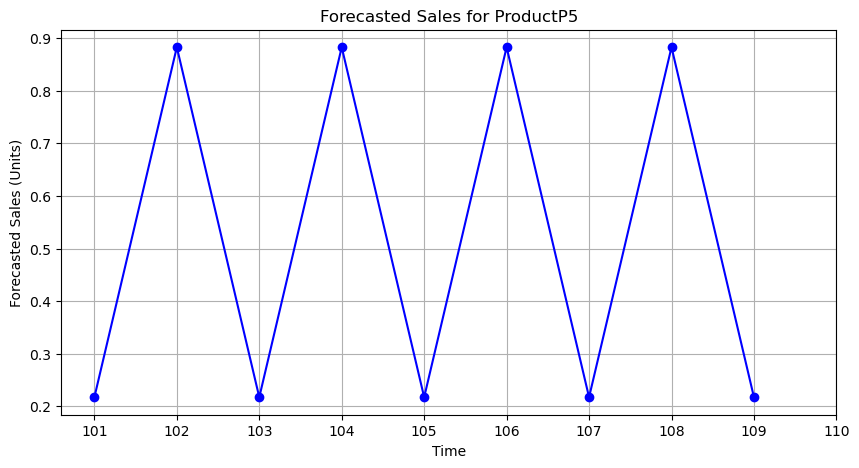

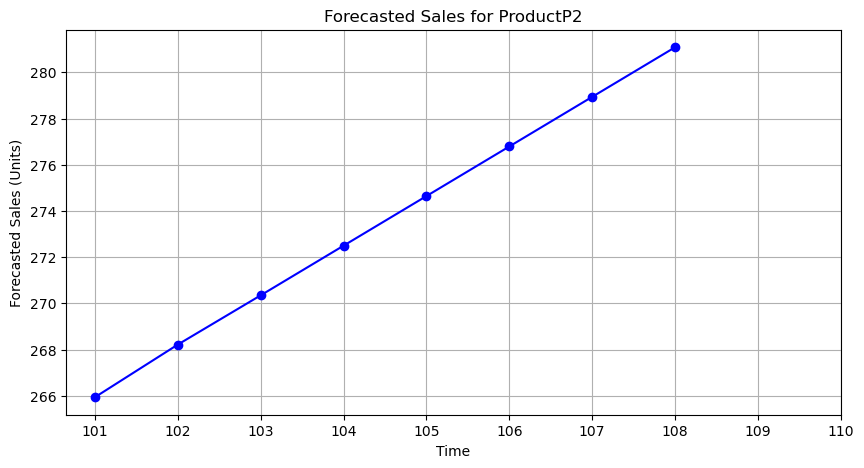

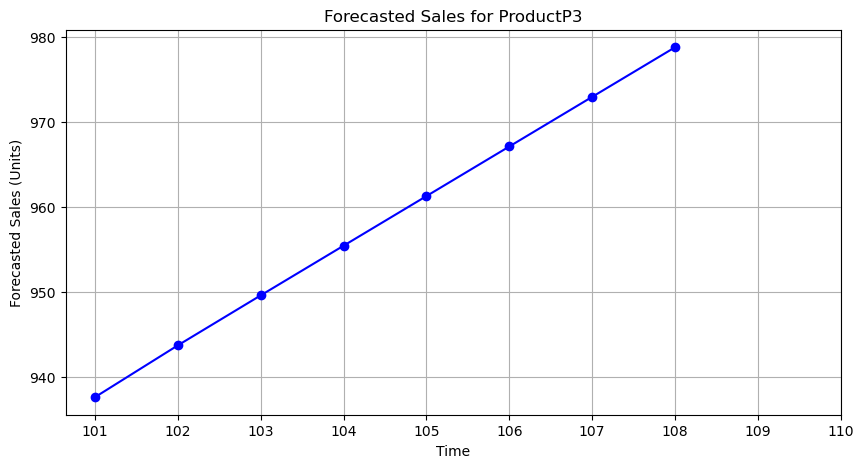

NameError: name 'tools' is not defined

In [196]:
# Plot individual graphs for each product
for product in final_forecast_df.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(final_forecast_df.index, final_forecast_df[product], marker='o', linestyle='-', color='b')
    plt.xlabel("Time")
    plt.ylabel("Forecasted Sales (Units)")
    plt.title(f"Forecasted Sales for {product}")
    plt.xticks(final_forecast_df.index)  # Ensure whole numbers on the x-axis
    plt.grid(True)
    plt.show()

# Display the cleaned and finalized forecasted data
tools.display_dataframe_to_user(name="Final Forecasted Sales Data", dataframe=final_forecast_df)

In [215]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define and fit ARIMAX model (including exogenous variables)
model = SARIMAX(train, exog=exog_train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
results = model.fit()

# Forecasting
forecast = results.forecast(steps=len(test), exog=exog_test)

# Evaluate accuracy
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test, forecast)
print(f"Mean Absolute Error: {mae}")


Mean Absolute Error: 26.294242674306126


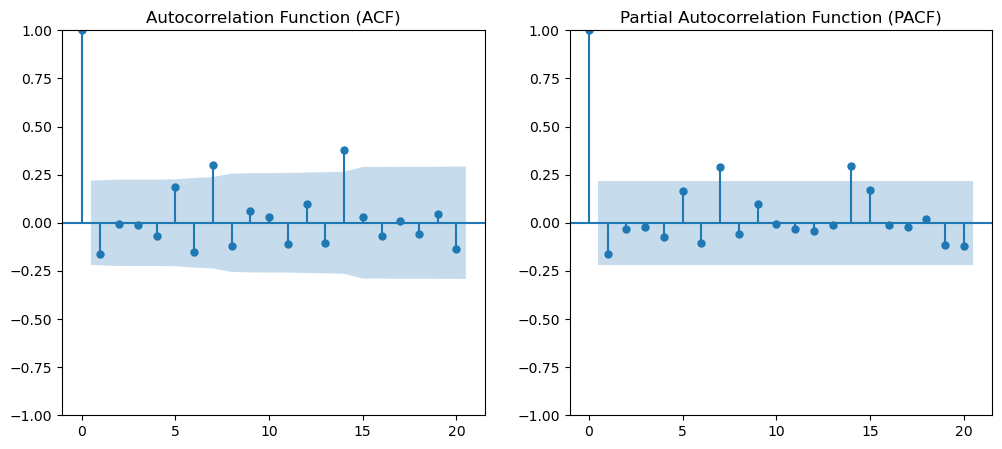

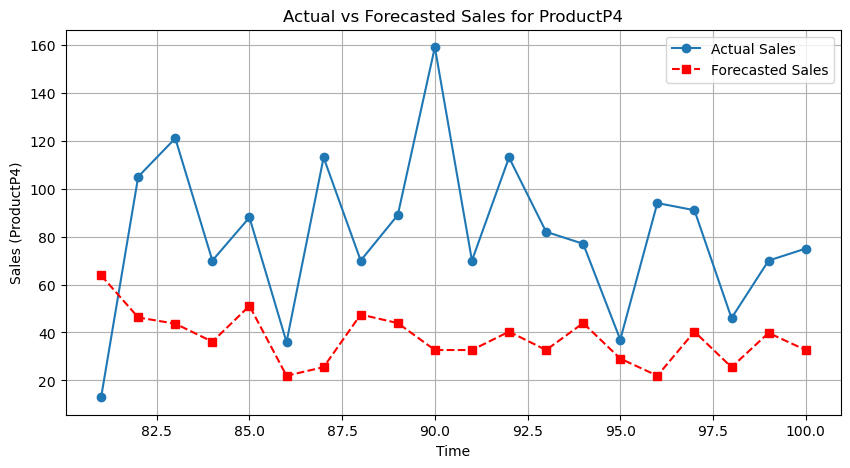

ModuleNotFoundError: No module named 'ace_tools'

In [219]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset again since the execution state was reset
#file_path = "/mnt/data/time series data.csv"
#df = pd.read_csv(file_path)

# Convert time column to datetime format if necessary (assuming "t" is the time index)
df.index = pd.RangeIndex(start=1, stop=len(df) + 1, step=1)

# Define dependent and explanatory variables
endog = df["ProductP4"]  # Dependent Variable
exog = df[["price", "temperature"]]  # Explanatory Variables

# Train-test split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train, test = endog[:train_size], endog[train_size:]
exog_train, exog_test = exog[:train_size], exog[train_size:]

# Check for stationarity using Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(train)
p_value = adf_result[1]

# Apply differencing if p-value > 0.05 (indicating non-stationarity)
if p_value > 0.05:
    train_diff = train.diff().dropna()
    test_diff = test.diff().dropna()
    diff_applied = True
else:
    train_diff = train
    test_diff = test
    diff_applied = False

# Plot ACF & PACF for determining AR and MA terms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(train_diff, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(train_diff, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")
plt.show()

# Fit ARIMAX model (including exogenous variables)
order = (1, 1, 1) if diff_applied else (1, 0, 1)  # Adjust differencing
model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=(0, 0, 0, 0))
results = model.fit()

# Forecasting
forecast = results.forecast(steps=len(test), exog=exog_test)

# Compute accuracy metrics
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

# Display accuracy
accuracy_metrics = pd.DataFrame({
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse]
})

# Plot actual vs. forecasted values
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label="Actual Sales", marker='o', linestyle='-')
plt.plot(test.index, forecast, label="Forecasted Sales", marker='s', linestyle='--', color="red")
plt.xlabel("Time")
plt.ylabel("Sales (ProductP4)")
plt.title("Actual vs Forecasted Sales for ProductP4")
plt.legend()
plt.grid(True)
plt.show()

# Display forecast accuracy
import ace_tools as tools
tools.display_dataframe_to_user(name="Forecast Accuracy for Product P4", dataframe=accuracy_metrics)


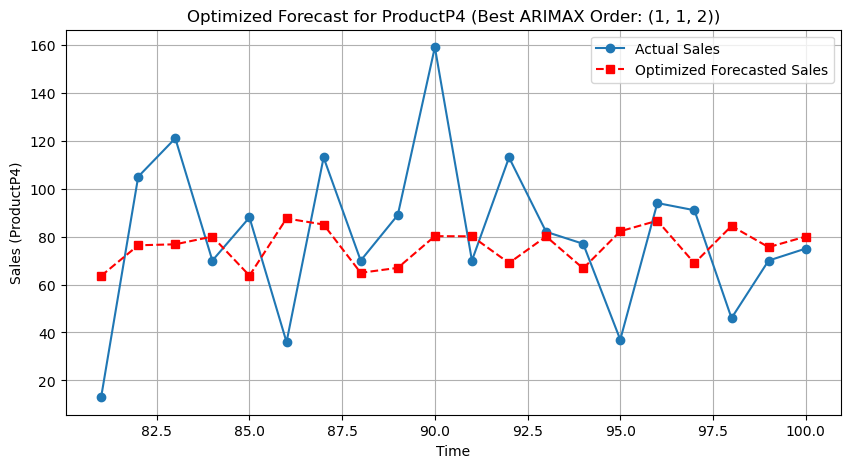

ModuleNotFoundError: No module named 'ace_tools'

In [221]:
# Reload the dataset after reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools
import warnings

warnings.filterwarnings("ignore")

# Load the dataset
#file_path = "/mnt/data/time series data.csv"
#df = pd.read_csv(file_path)

# Convert time column to datetime format if necessary (assuming "t" is the time index)
df.index = pd.RangeIndex(start=1, stop=len(df) + 1, step=1)

# Define dependent and explanatory variables for Product P4
endog = df["ProductP4"]  # Dependent Variable
exog = df[["price", "temperature"]]  # Explanatory Variables

# Train-test split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train, test = endog[:train_size], endog[train_size:]
exog_train, exog_test = exog[:train_size], exog[train_size:]

# Check for stationarity using Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(train)
p_value = adf_result[1]

# Apply differencing if p-value > 0.05 (indicating non-stationarity)
if p_value > 0.05:
    train_diff = train.diff().dropna()
    test_diff = test.diff().dropna()
    diff_applied = True
else:
    train_diff = train
    test_diff = test
    diff_applied = False

# Optimize ARIMAX model parameters by iterating over (p,d,q)
p = range(0, 3)  # AR terms
d = range(0, 2)  # Differencing
q = range(0, 3)  # MA terms

# Generate all possible combinations
pdq_combinations = list(itertools.product(p, d, q))

# Track the best model
best_aic = float("inf")
best_order = None
best_model = None

# Iterate over combinations and find the best model based on AIC
for order in pdq_combinations:
    try:
        model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=(0, 0, 0, 0))
        results = model.fit()
        
        # Track best model
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
            
    except:
        continue

# Forecast with the best model
forecast_optimized = best_model.forecast(steps=len(test), exog=exog_test)

# Compute new accuracy metrics
mae_opt = mean_absolute_error(test, forecast_optimized)
mse_opt = mean_squared_error(test, forecast_optimized)
rmse_opt = np.sqrt(mse_opt)

# Display new accuracy metrics
accuracy_metrics_opt = pd.DataFrame({
    "MAE": [mae_opt],
    "MSE": [mse_opt],
    "RMSE": [rmse_opt]
})

# Plot actual vs. optimized forecasted values
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label="Actual Sales", marker='o', linestyle='-')
plt.plot(test.index, forecast_optimized, label="Optimized Forecasted Sales", marker='s', linestyle='--', color="red")
plt.xlabel("Time")
plt.ylabel("Sales (ProductP4)")
plt.title(f"Optimized Forecast for ProductP4 (Best ARIMAX Order: {best_order})")
plt.legend()
plt.grid(True)
plt.show()

# Display optimized forecast accuracy
import ace_tools as tools
tools.display_dataframe_to_user(name="Optimized Forecast Accuracy for Product P4", dataframe=accuracy_metrics_opt)


In [231]:
# Forecast
forecast = results.predict(start=len(train), end=len(df)-1, exog=exog_test)

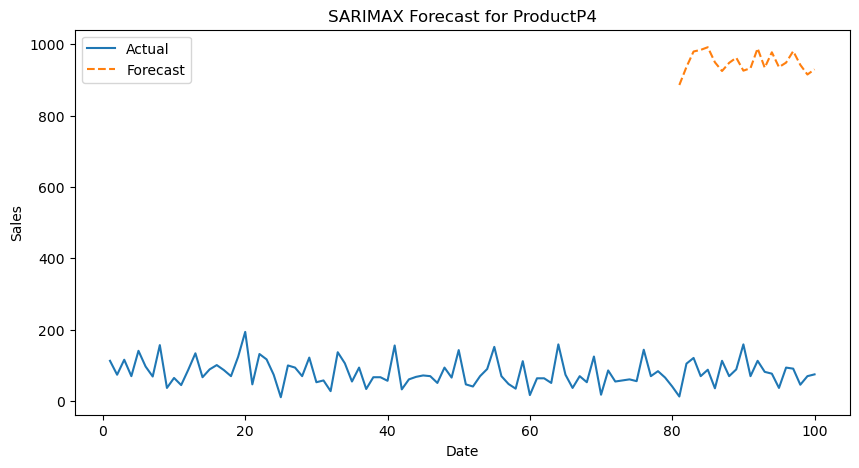

In [233]:
# Plot Forecast
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['ProductP4'], label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('SARIMAX Forecast for ProductP4')
plt.legend()
plt.show()

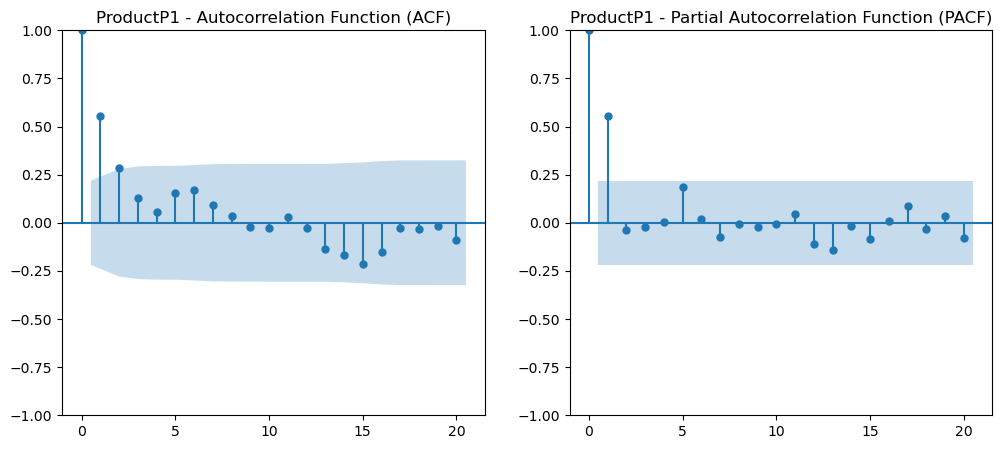

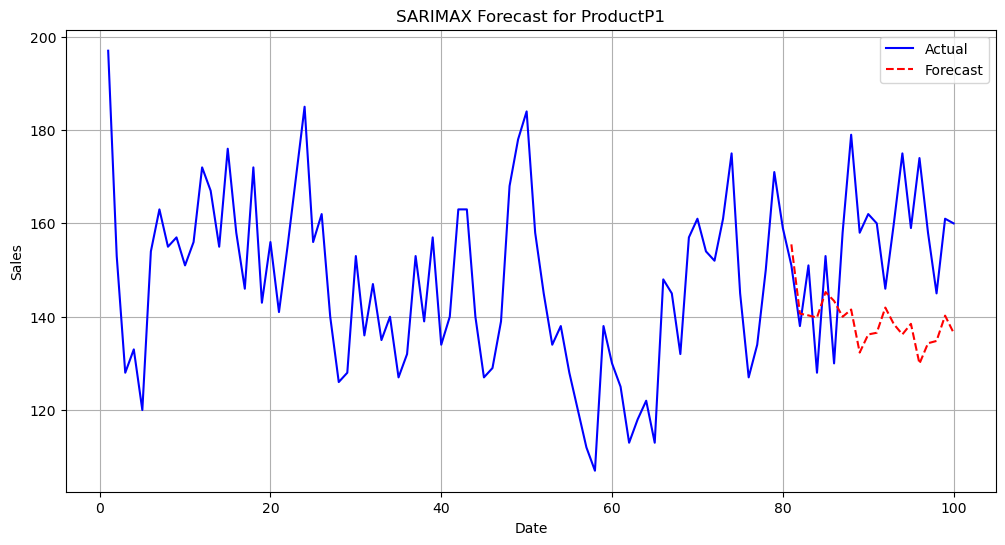

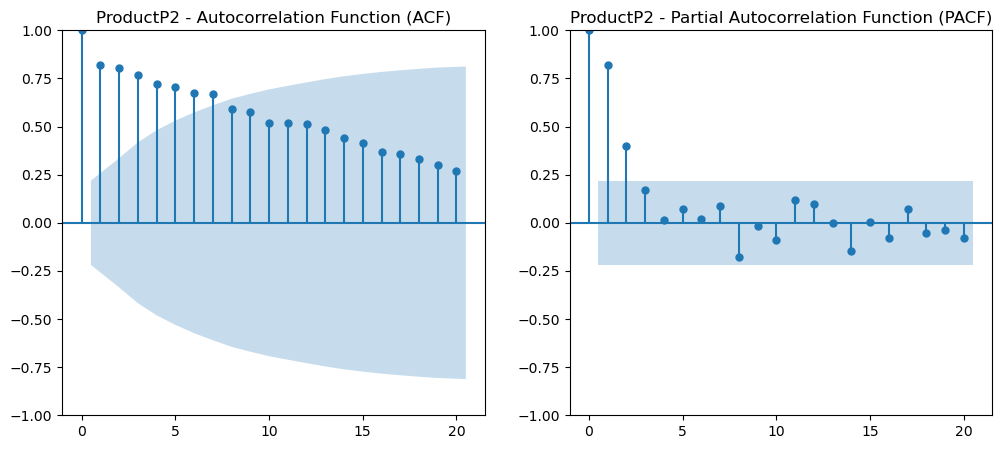

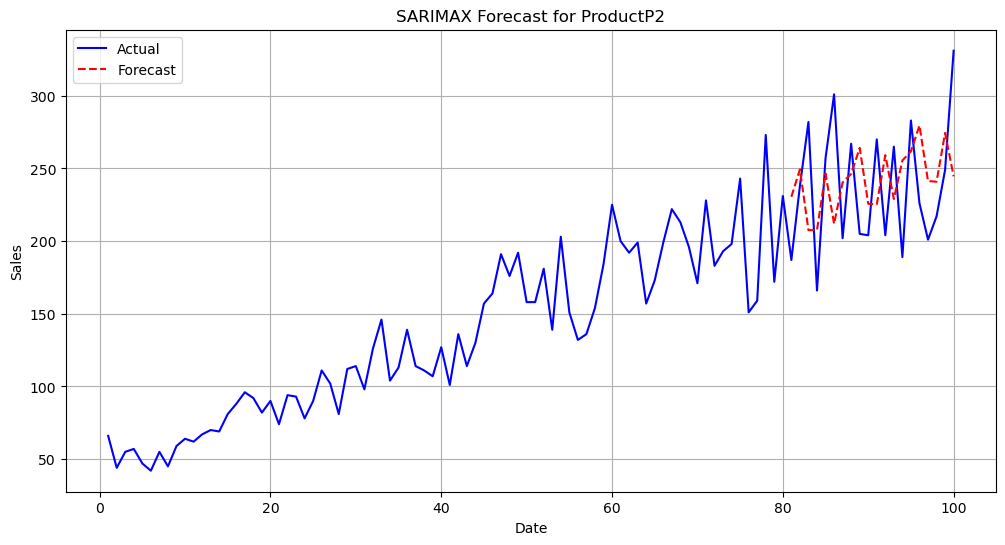

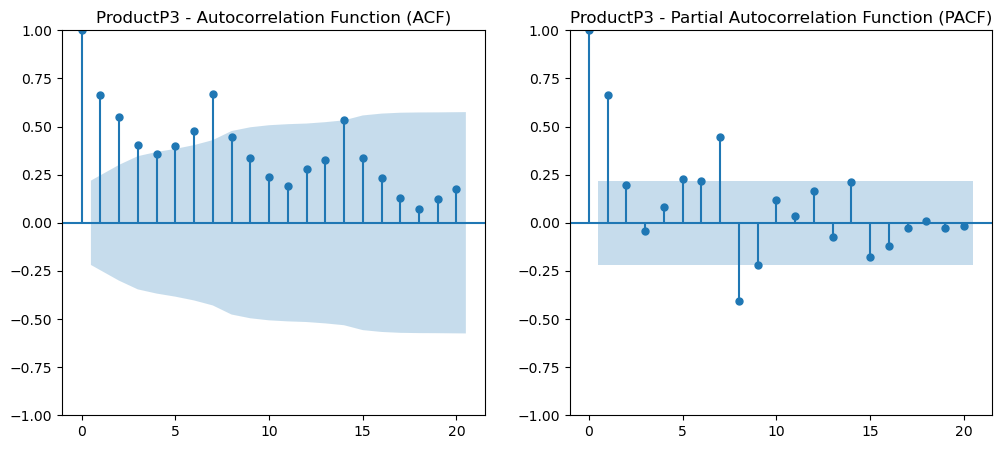

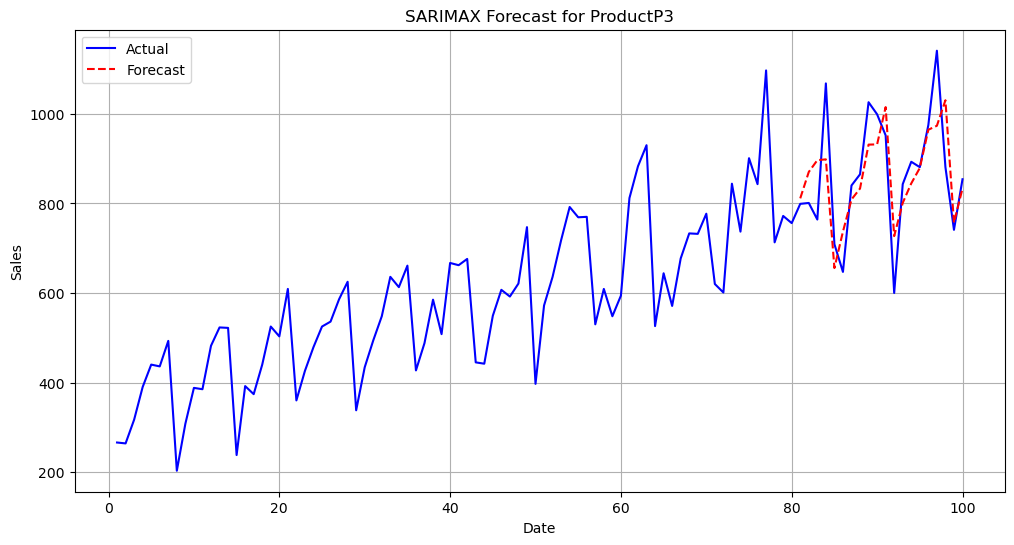

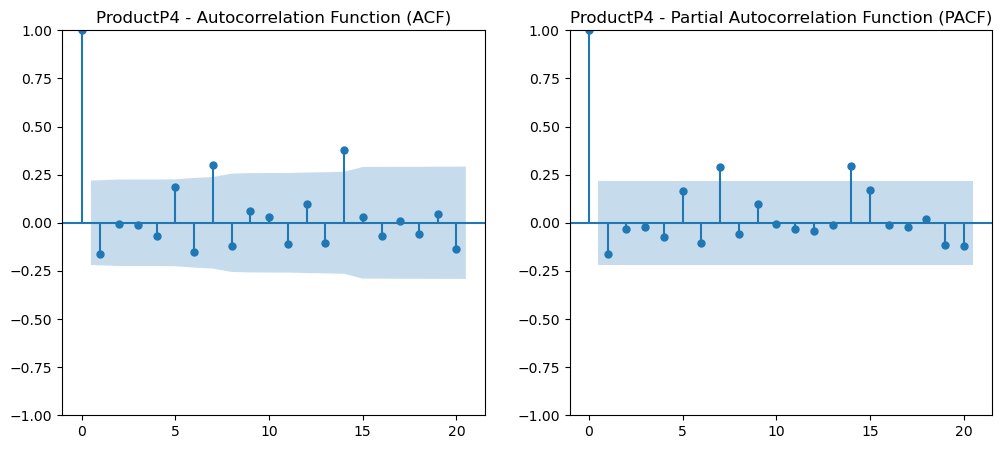

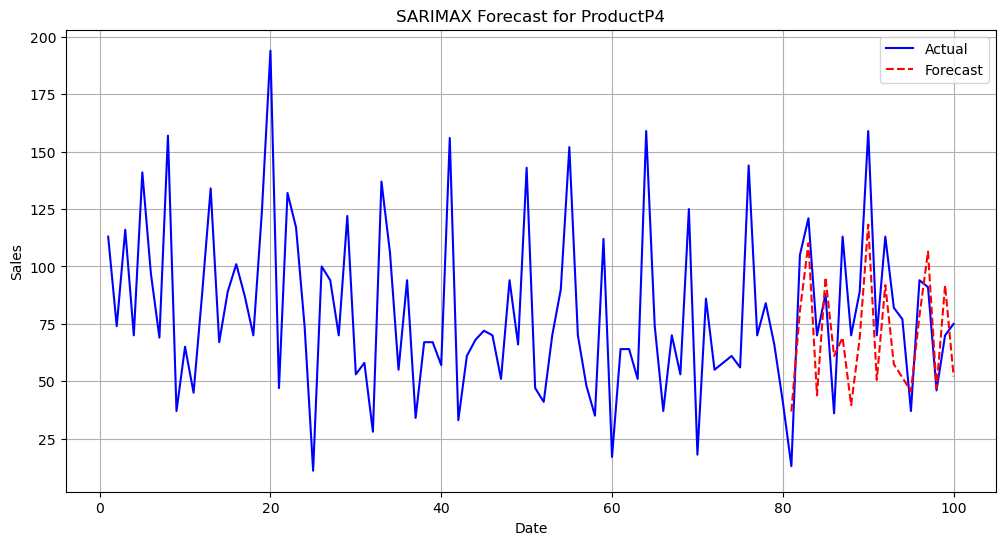

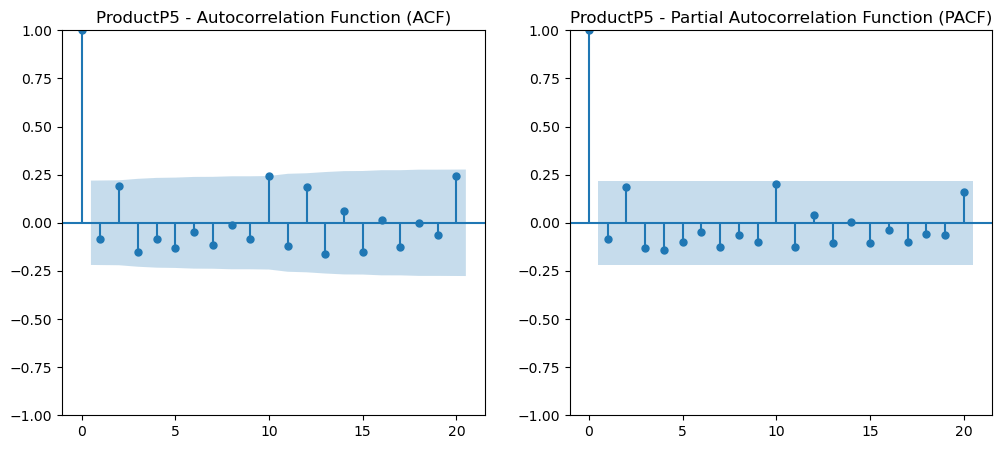

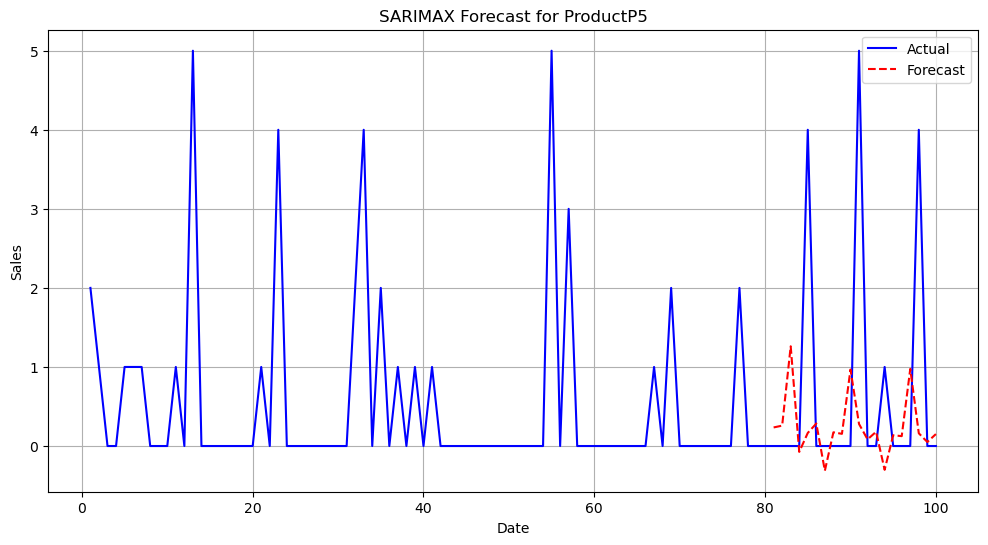

In [235]:
# Forecasting all products
products = ['ProductP1', 'ProductP2', 'ProductP3', 'ProductP4', 'ProductP5']
for product in products:
    endog = df[product]
    exog = df[['price', 'temperature']] if product == 'ProductP4' else None

    # Train-test split
    train_size = int(len(df) * 0.8)
    train, test = endog[:train_size], endog[train_size:]
    exog_train, exog_test = (exog[:train_size], exog[train_size:]) if exog is not None else (None, None)

    # ACF & PACF plots for stationarity analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_acf(train.dropna(), ax=axes[0])
    axes[0].set_title(f"{product} - Autocorrelation Function (ACF)")
    plot_pacf(train.dropna(), ax=axes[1])
    axes[1].set_title(f"{product} - Partial Autocorrelation Function (PACF)")
    plt.show()

    # Fit SARIMAX Model
    model = SARIMAX(train.dropna(), exog=exog_train, order=(1,1,1), seasonal_order=(1,1,1,7))
    results = model.fit()

    # Forecast
    forecast = results.predict(start=len(train), end=len(df)-1, exog=exog_test)

    # Plot Forecast
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[product], label='Actual', color='blue')
    plt.plot(test.index, forecast, label='Forecast', linestyle='dashed', color='red')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title(f'SARIMAX Forecast for {product}')
    plt.legend()
    plt.grid(True)
    plt.show()

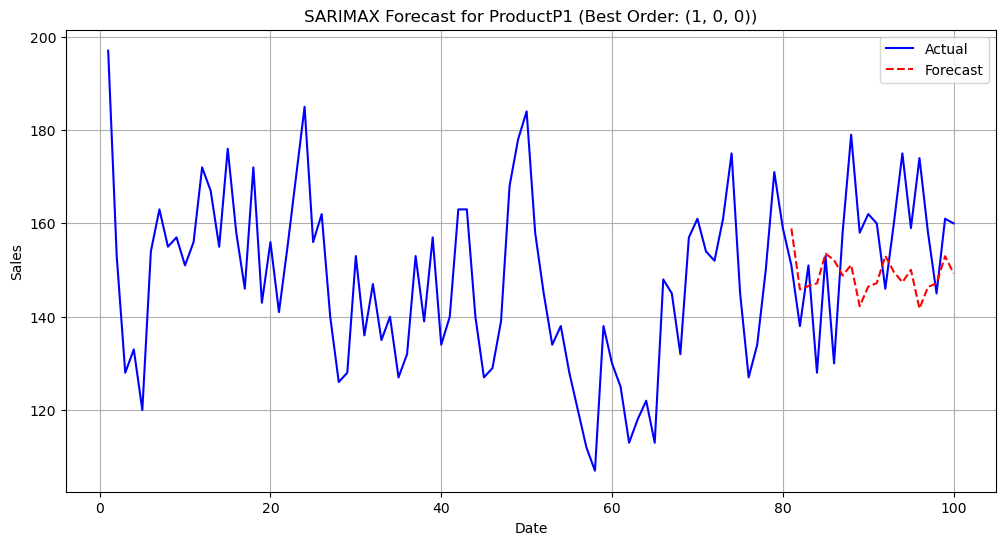

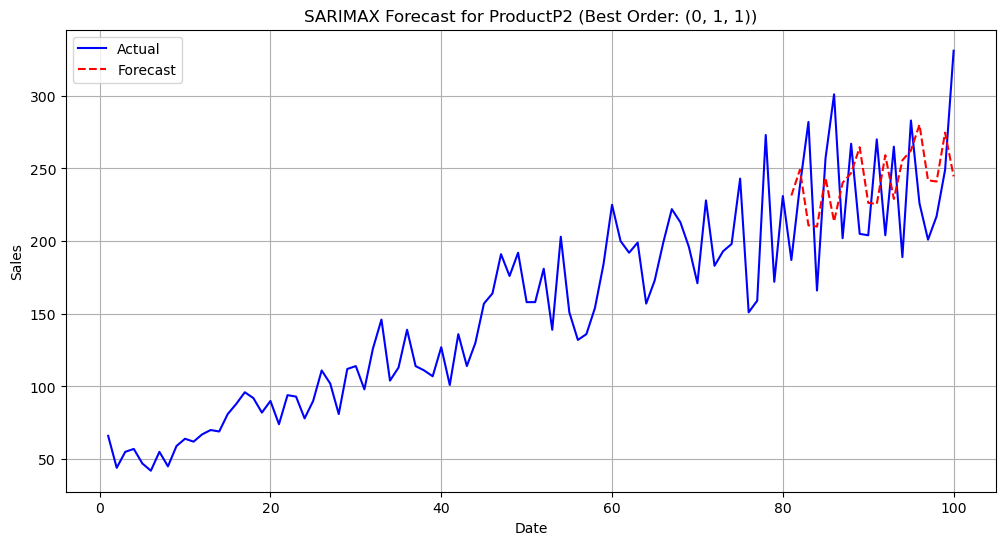

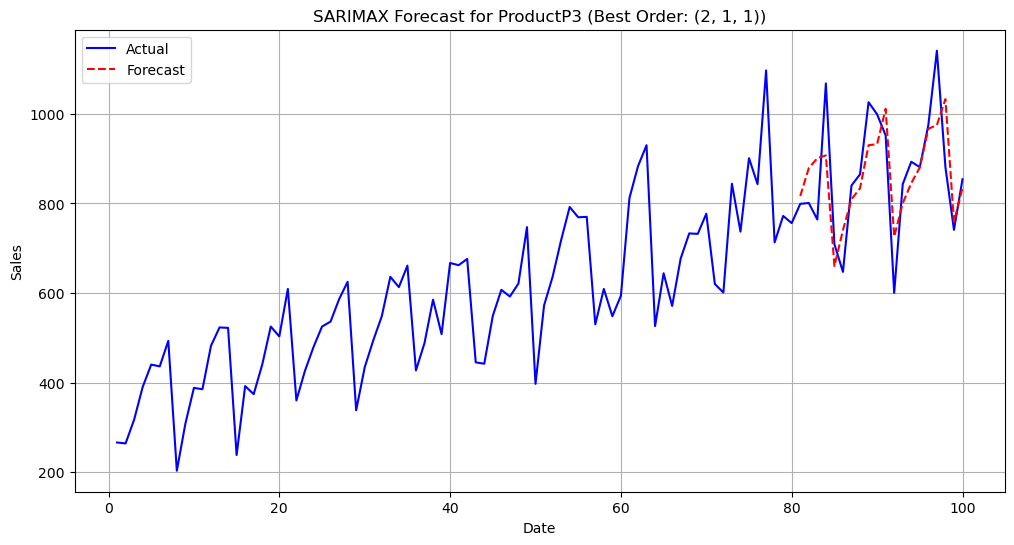

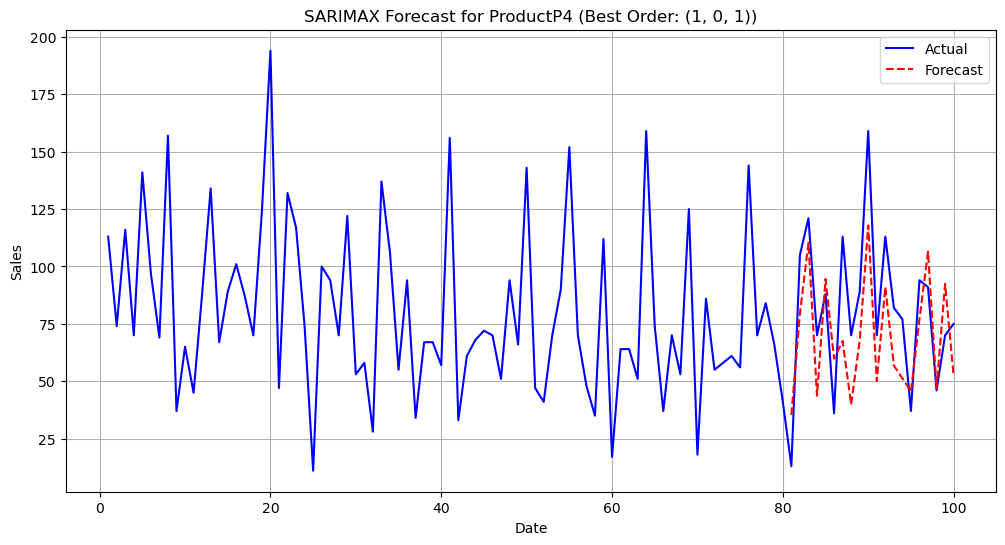

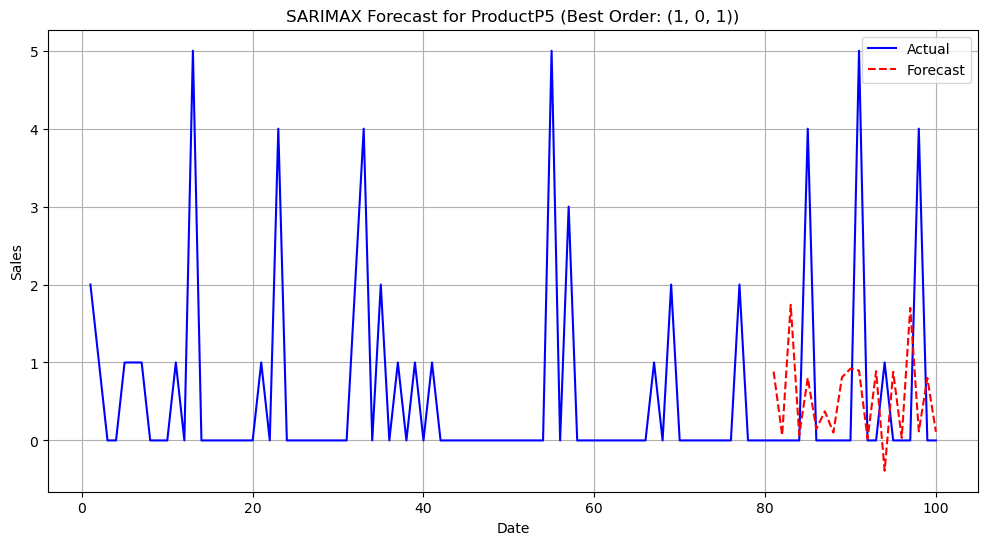

ModuleNotFoundError: No module named 'ace_tools'

In [241]:
# Manually tuning SARIMA parameters for each product

# Define p, d, q ranges for manual tuning
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

# Dictionary to store forecasts and accuracy metrics
forecast_results = {}
accuracy_results = {}

# Forecast all products using SARIMAX
for product in products:
    endog = df[product]
    exog = df[['price', 'temperature']] if product == 'ProductP4' else None

    # Train-test split
    train_size = int(len(df) * 0.8)
    train, test = endog[:train_size], endog[train_size:]
    exog_train, exog_test = (exog[:train_size], exog[train_size:]) if exog is not None else (None, None)

    # Check stationarity
    adf_test = adfuller(train.dropna())
    p_value = adf_test[1]

    # Apply differencing if needed
    d = 1 if p_value > 0.05 else 0

    # Find the best SARIMA order manually
    best_aic = float("inf")
    best_order = None
    best_model = None

    for p in p_values:
        for q in q_values:
            try:
                model = SARIMAX(train.dropna(), exog=exog_train, order=(p, d, q), seasonal_order=(1, 1, 1, 7))
                results = model.fit()
                
                # Track best model based on AIC
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model = results

            except:
                continue

    # Forecast with the best model
    forecast = best_model.predict(start=len(train), end=len(df)-1, exog=exog_test)

    # Store forecasted values
    forecast_results[product] = forecast

    # Compute forecast accuracy metrics
    mae = mean_absolute_error(test.dropna(), forecast[:len(test)].dropna())
    mse = mean_squared_error(test.dropna(), forecast[:len(test)].dropna())
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test.dropna() - forecast[:len(test)].dropna()) / test.dropna())) * 100

    # Store accuracy metrics
    accuracy_results[product] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE (%)": mape}

    # Plot Forecast
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[product], label='Actual', color='blue')
    plt.plot(test.index, forecast, label='Forecast', linestyle='dashed', color='red')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title(f'SARIMAX Forecast for {product} (Best Order: {best_order})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Convert forecast results into a DataFrame
forecast_df = pd.DataFrame(forecast_results)

# Convert accuracy results into a DataFrame
accuracy_df = pd.DataFrame(accuracy_results).T

# Save forecasted data to CSV
forecast_file_path = "D:/Personal/MSc/MSc. Data Science/Lecture Notes/2. Principles of DS/Assignment and Passpapers/Assignments/Portfolio/Group Work/all_products_forecast_manual.csv"
forecast_df.to_csv(forecast_file_path, index=True)

# Save accuracy metrics to CSV
accuracy_file_path = "D:/Personal/MSc/MSc. Data Science/Lecture Notes/2. Principles of DS/Assignment and Passpapers/Assignments/Portfolio/Group Work/forecast_accuracy_manual.csv"
accuracy_df.to_csv(accuracy_file_path, index=True)

# Display accuracy metrics
import ace_tools as tools
tools.display_dataframe_to_user(name="Forecast Accuracy Metrics", dataframe=accuracy_df)

# Provide download links
forecast_file_path, accuracy_file_path
